# *Advanced Cardiovascular Disease Prediction Pipeline*

## **Data Downloading**

In [1]:
# !pip install -q kaggle

In [2]:
# from google.colab import files
# files.upload()

In [3]:
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

In [4]:
# !kaggle datasets download -d noeyislearning/framingham-heart-study

In [5]:
# !unzip -q framingham-heart-study.zip

## **Import Libraries**

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

## **Data Loading**

In [7]:
df = pd.read_csv('framingham_heart_study.csv')
display(df.head())

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## **Exploratory Data Analysis (EDA)**

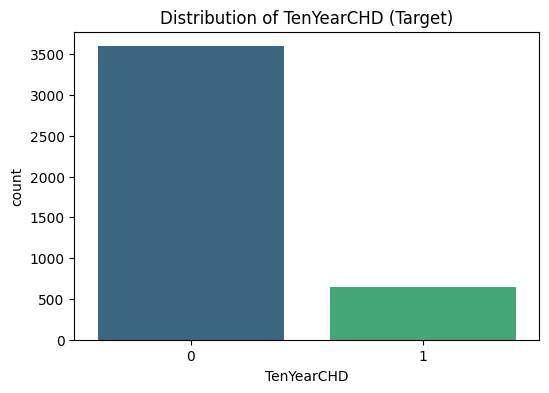

In [8]:
# Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='TenYearCHD', hue='TenYearCHD', palette='viridis', legend=False)
plt.title('Distribution of TenYearCHD (Target)')
plt.show()

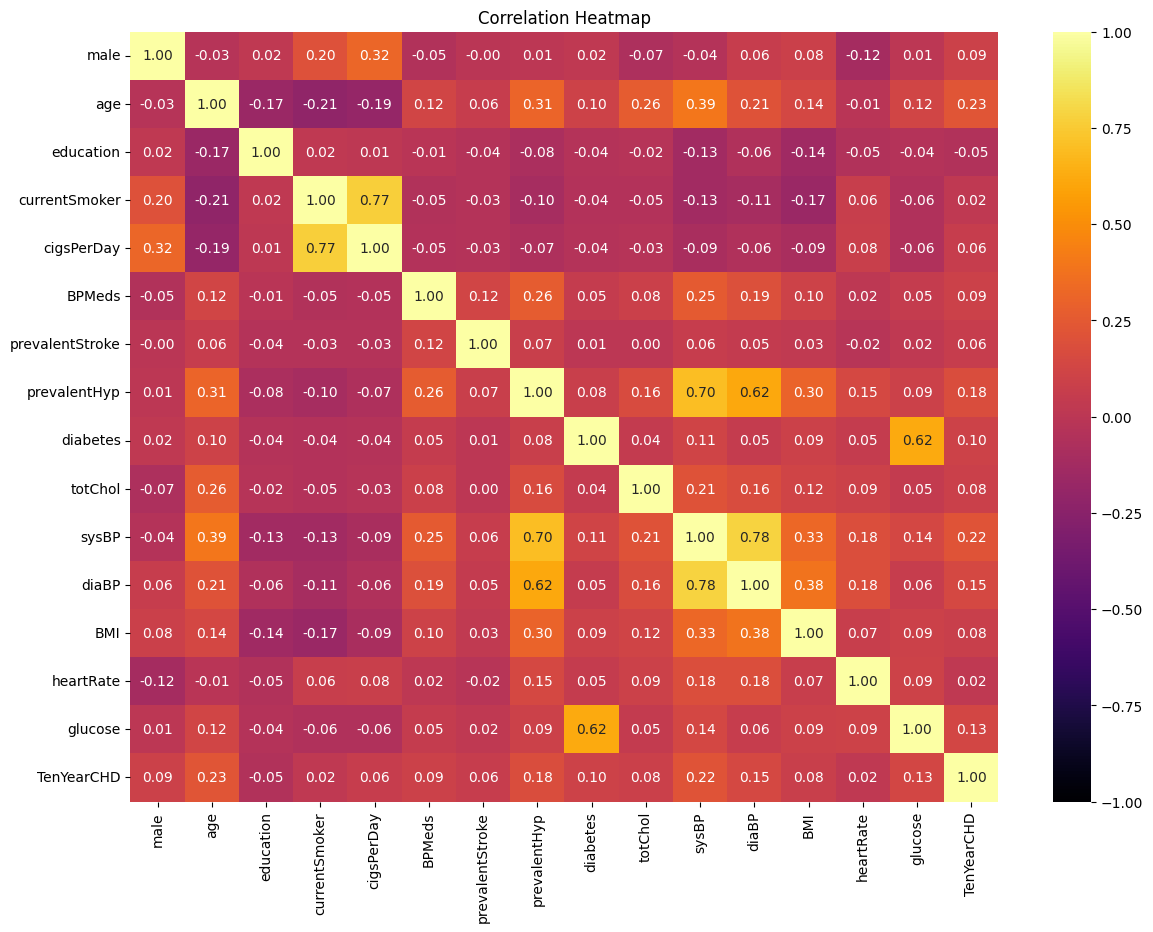

In [9]:
# 2. Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='inferno', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

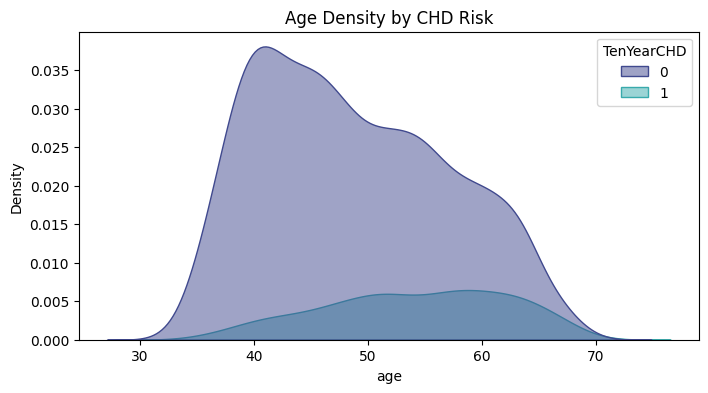

In [10]:
# 3. Age via Density Plot
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x='age', hue='TenYearCHD', fill=True, palette='mako', alpha=0.5)
plt.title('Age Density by CHD Risk')
plt.show()

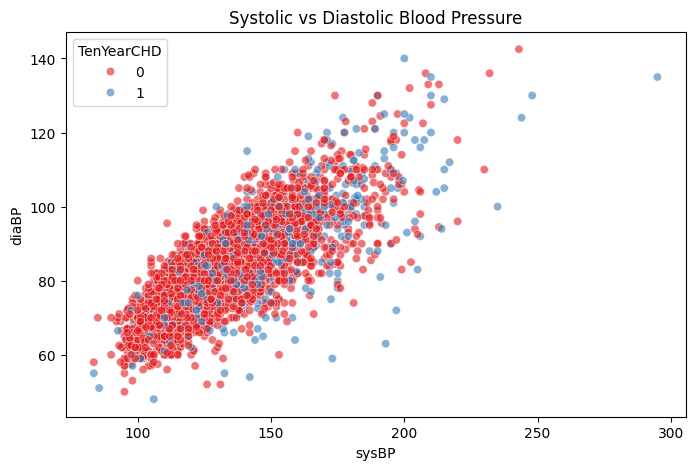

In [11]:
# 4. SysBP vs DiaBP
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='sysBP', y='diaBP', hue='TenYearCHD', alpha=0.6, palette='Set1')
plt.title('Systolic vs Diastolic Blood Pressure')
plt.show()

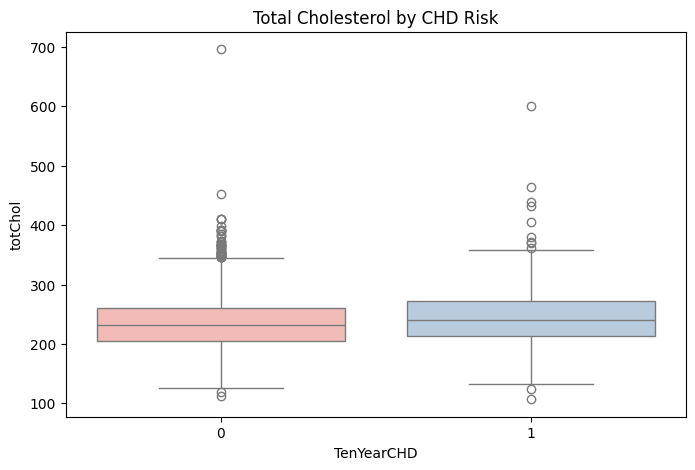

In [12]:
# 5. Boxplot of Total Cholesterol by CHD Risk
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='TenYearCHD', y='totChol', hue='TenYearCHD', palette='Pastel1', legend=False)
plt.title('Total Cholesterol by CHD Risk')
plt.show()

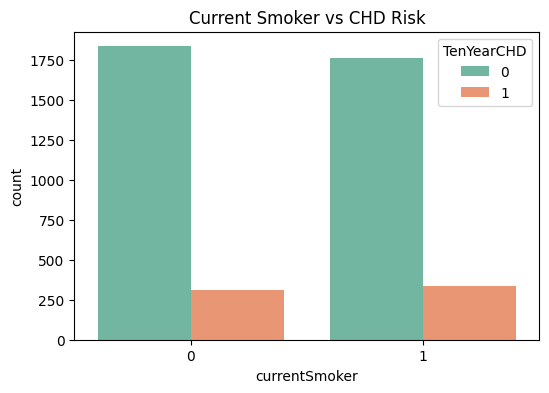

In [13]:
# 6. Current Smoker vs CHD Risk
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='currentSmoker', hue='TenYearCHD', palette='Set2')
plt.title('Current Smoker vs CHD Risk')
plt.show()

## **Advanced Medical Feature Engineering**

In [14]:
# Adding Medical Features: Pulse Pressure and Mean Arterial Pressure (MAP)
df['PulsePressure'] = df['sysBP'] - df['diaBP']
df['MAP'] = df['diaBP'] + (df['sysBP'] - df['diaBP']) / 3

display(df[['sysBP', 'diaBP', 'PulsePressure', 'MAP']].head())

,sysBP,diaBP,PulsePressure,MAP
0,106.0,70.0,36.0,82.000000
1,121.0,81.0,40.0,94.333333
2,127.5,80.0,47.5,95.833333
3,150.0,95.0,55.0,113.333333
4,130.0,84.0,46.0,99.333333


## **Advanced Data Preprocessing (KNN Imputation)**

In [15]:
# Categorical vs Numerical Detection
cat_cols = ['education', 'BPMeds', 'currentSmoker', 'prevalentStroke', 'prevalentHyp', 'diabetes']
num_cols = [c for c in df.columns if c not in cat_cols and c != 'TenYearCHD']

# Mode imputation for categorical
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# KNN Imputation for numerical columns to strictly retain data distributions
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
df[num_cols] = knn_imputer.fit_transform(df[num_cols])

print("Missing values completely removed:\n", df.isnull().sum().sum())

Missing values completely removed:
 0


## **Train-Test Split and Advanced Resampling (`SMOTETomek`)**

In [16]:
X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# SMOTETomek combines oversampling (SMOTE) with undersampling (Tomek links cleanup of noisy borders)
smt = SMOTETomek(random_state=42, n_jobs=-1)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print(f"Original Training Class balance:\n{y_train.value_counts()}")
print(f"Training Class balance post-SMOTETomek:\n{y_train_res.value_counts()}")

Original Training Class balance:
TenYearCHD
0    2877
1     515
Name: count, dtype: int64
Training Class balance post-SMOTETomek:
TenYearCHD
0    2856
1    2856
Name: count, dtype: int64


## **Intelligent Modeling (Gradient Boosting Base Models)**

In [17]:
# Initializing LightGBM and XGBoost next to a strong Random Forest estimator
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
}

# Train models and predictions
preds = {}
probs = {}
for name, model in models.items():
    print(f"Training Baseline {name}...")
    model.fit(X_train_scaled, y_train_res)
    preds[name] = model.predict(X_test_scaled)
    probs[name] = model.predict_proba(X_test_scaled)[:, 1]
print("Baseline robust modeling complete.")

Training Baseline Random Forest...
Training Baseline XGBoost...
Training Baseline LightGBM...
Baseline robust modeling complete.


## **Evaluation Metrics (Base Models DataFrame)**

In [18]:
def get_metrics_df(y_true, predictions, probabilities, models_dict):
    metrics = []
    for name in models_dict.keys():
        acc = accuracy_score(y_true, predictions[name])
        prec = precision_score(y_true, predictions[name], zero_division=0)
        rec = recall_score(y_true, predictions[name], zero_division=0)
        f1 = f1_score(y_true, predictions[name], zero_division=0)
        auc_val = roc_auc_score(y_true, probabilities[name])
        metrics.append([acc, prec, rec, f1, auc_val])
    df_metrics = pd.DataFrame(metrics, columns=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'], index=list(models_dict.keys()))
    return df_metrics

base_metrics_df = get_metrics_df(y_test, preds, probs, models)
display(base_metrics_df)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Random Forest,0.820755,0.305085,0.139535,0.191489,0.639756
XGBoost,0.799528,0.226667,0.131783,0.166667,0.586096
LightGBM,0.811321,0.253968,0.124031,0.166667,0.596932


## **Confusion Matrix - Base Models**

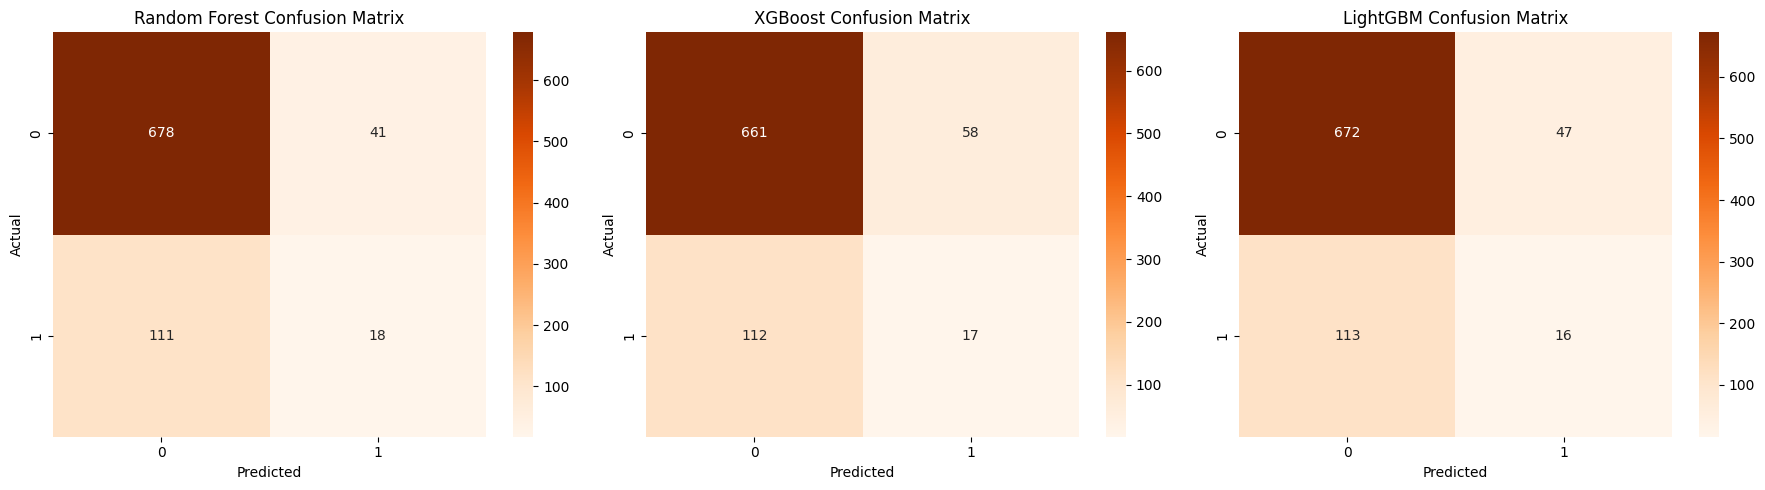

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, name in enumerate(models.keys()):
    cm = confusion_matrix(y_test, preds[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

## **ROC-AUC Curves - Base Models**

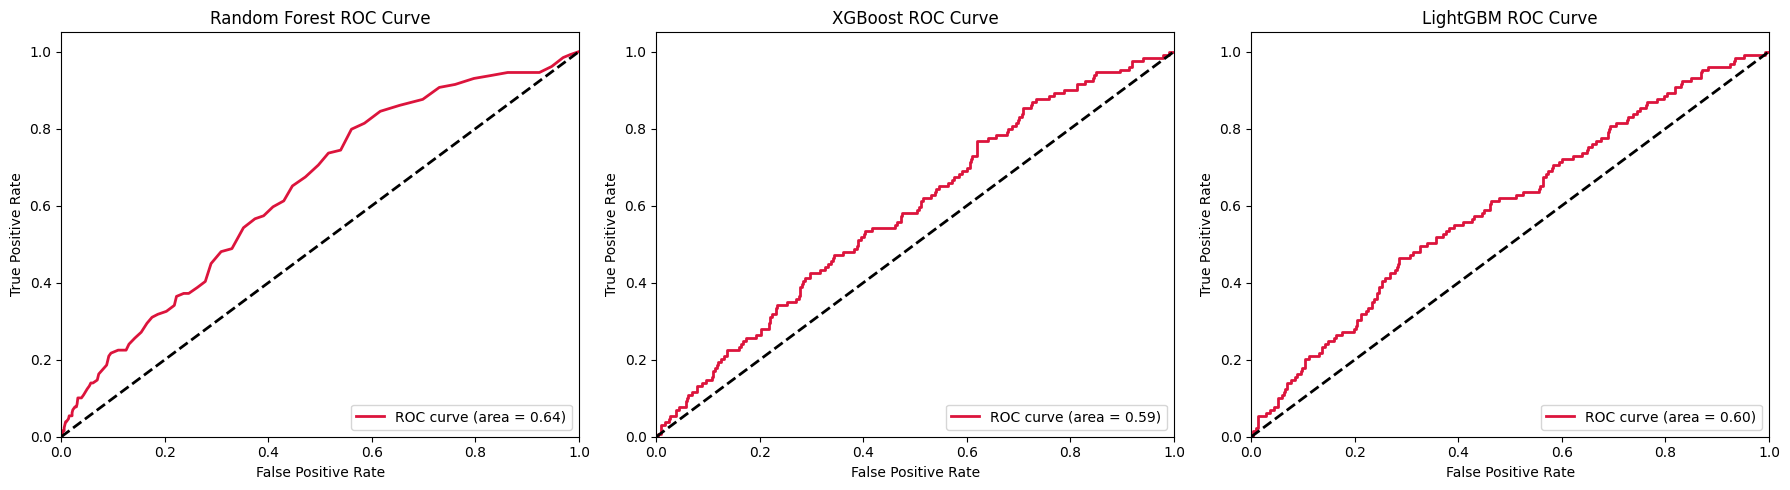

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, name in enumerate(models.keys()):
    fpr, tpr, _ = roc_curve(y_test, probs[name])
    roc_auc = auc(fpr, tpr)
    axes[i].plot(fpr, tpr, color='crimson', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    axes[i].plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_title(f'{name} ROC Curve')
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend(loc="lower right")
plt.tight_layout()
plt.show()

## **Hyperparameter Tuning via RandomizedSearchCV and Stacking**

In [21]:
# Fine Tuning XGBoost
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}
print("Tuning XGBoost...")
xgb_rand = RandomizedSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42), 
                              xgb_params, n_iter=5, cv=3, scoring='f1', n_jobs=-1, random_state=42)
xgb_rand.fit(X_train_scaled, y_train_res)

Tuning XGBoost...


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value 

In [22]:
# Fine Tuning LightGBM
lgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 7, -1],
    'learning_rate': [0.01, 0.1, 0.2],
    'num_leaves': [31, 50]
}
print("Tuning LightGBM...")
lgb_rand = RandomizedSearchCV(LGBMClassifier(random_state=42, verbose=-1), 
                              lgb_params, n_iter=5, cv=3, scoring='f1', n_jobs=-1, random_state=42)
lgb_rand.fit(X_train_scaled, y_train_res)

Tuning LightGBM...


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","LGBMClassifie...2, verbose=-1)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 7, ...], 'n_estimators': [100, 200], 'num_leaves': [31, 50]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.

In [23]:
print("Building Dynamic Stacking Classifier...")
tuned_stacking = StackingClassifier(
    estimators=[
        ('xgb', xgb_rand.best_estimator_),
        ('lgb', lgb_rand.best_estimator_)
    ],
    final_estimator=LogisticRegression(class_weight='balanced'),
    cv=5,
    n_jobs=-1
)
tuned_stacking.fit(X_train_scaled, y_train_res)

Building Dynamic Stacking Classifier...


,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('xgb', ...), ('lgb', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...ht='balanced')
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks

In [24]:
tuned_models = {
    'Tuned XGBoost': xgb_rand.best_estimator_,
    'Tuned LightGBM': lgb_rand.best_estimator_,
    'Powerful Stacking': tuned_stacking
}

tuned_preds = {}
tuned_probs = {}
for name, model in tuned_models.items():
    tuned_preds[name] = model.predict(X_test_scaled)
    tuned_probs[name] = model.predict_proba(X_test_scaled)[:, 1]

## **Evaluation Metrics (Fine Tuned Models DataFrame)**

In [25]:
tuned_metrics_df = get_metrics_df(y_test, tuned_preds, tuned_probs, tuned_models)
display(tuned_metrics_df)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Tuned XGBoost,0.823113,0.315789,0.139535,0.193548,0.645988
Tuned LightGBM,0.808962,0.229508,0.108527,0.147368,0.582560
Powerful Stacking,0.803066,0.243243,0.139535,0.177340,0.628877


## **Confusion Matrix - Fine Tuned Models**

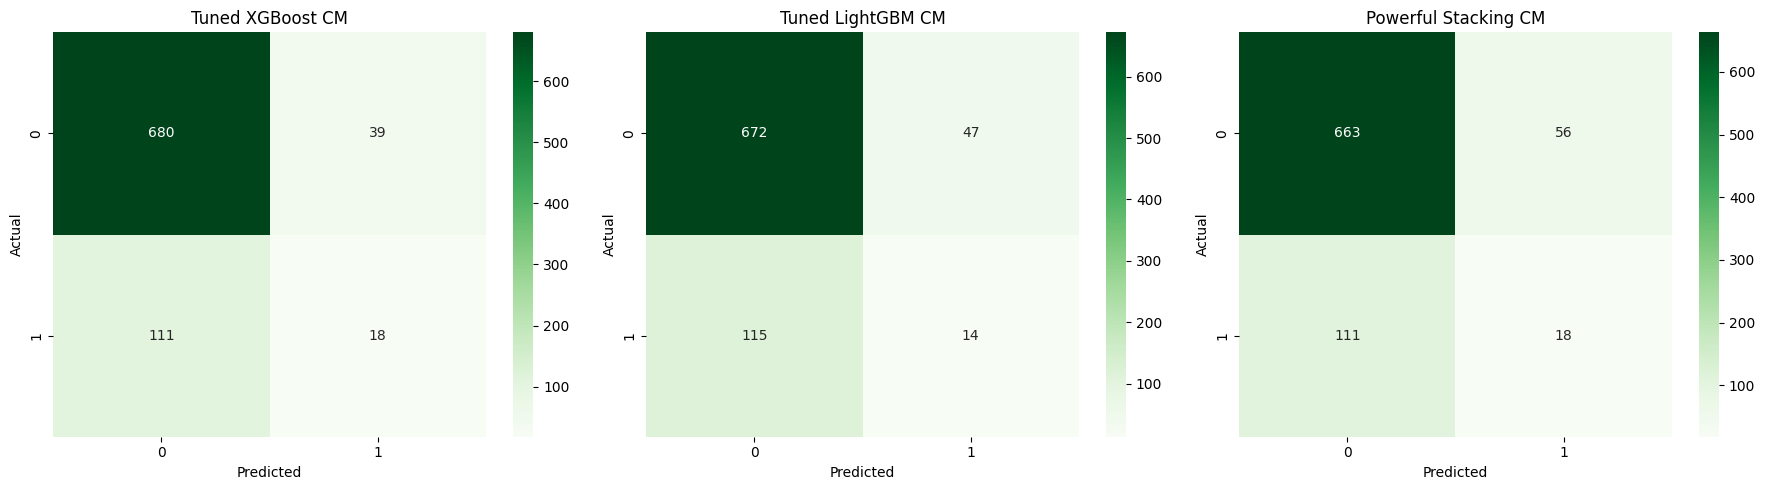

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, name in enumerate(tuned_models.keys()):
    cm = confusion_matrix(y_test, tuned_preds[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[i])
    axes[i].set_title(f'{name} CM')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

## **Individual Optimization Visualization Plots for Each Metric**

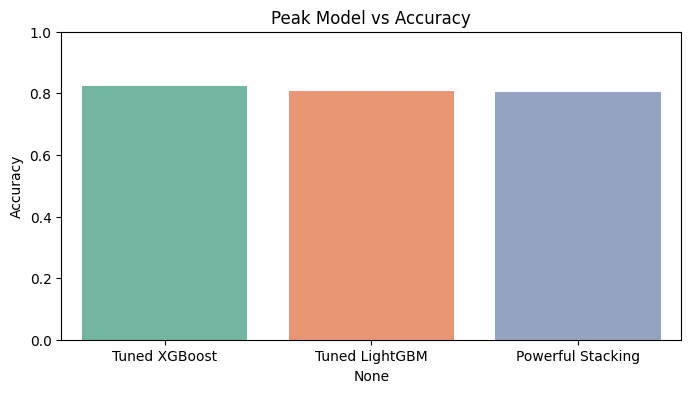

In [27]:
# Accuracy Plot
plt.figure(figsize=(8, 4))
sns.barplot(x=tuned_metrics_df.index, y=tuned_metrics_df['Accuracy'], palette='Set2', hue=tuned_metrics_df.index, legend=False)
plt.title('Peak Model vs Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)
plt.show()

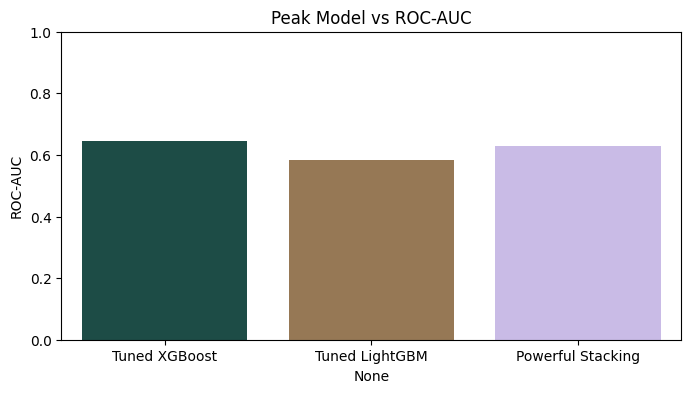

In [28]:
# ROC-AUC Plot
plt.figure(figsize=(8, 4))
sns.barplot(x=tuned_metrics_df.index, y=tuned_metrics_df['ROC-AUC'], palette='cubehelix', hue=tuned_metrics_df.index, legend=False)
plt.title('Peak Model vs ROC-AUC')
plt.ylabel('ROC-AUC')
plt.ylim(0, 1.0)
plt.show()

## **Robust ROC-AUC Curves - Fine Tuned Models**

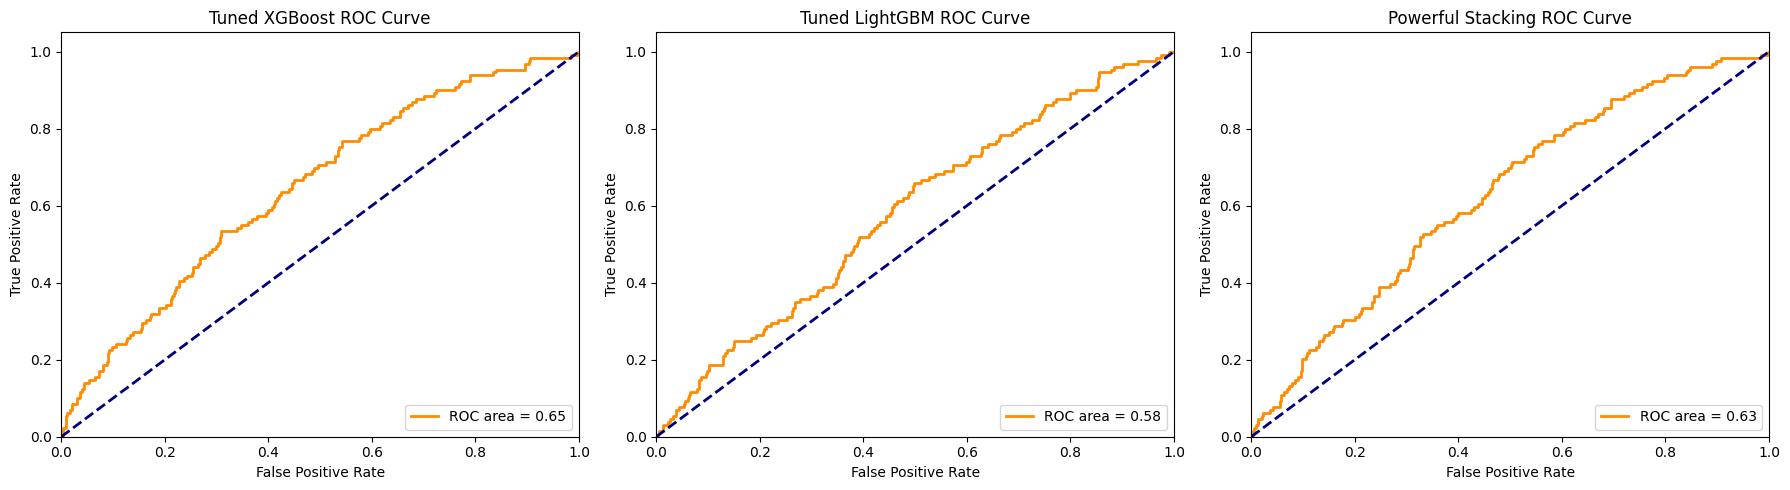

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, name in enumerate(tuned_models.keys()):
    fpr, tpr, _ = roc_curve(y_test, tuned_probs[name])
    roc_auc = auc(fpr, tpr)
    axes[i].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC area = {roc_auc:.2f}')
    axes[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_title(f'{name} ROC Curve')
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend(loc="lower right")
plt.tight_layout()
plt.show()

## **Test Predictions using Overall Best Model DataFrame**

In [30]:
# Extract Best Model Name based on F1 Score maximization
best_model_name = tuned_metrics_df['ROC-AUC'].idxmax()
print(f"The objectively best Advanced Model strictly considering ROC-AUC Score is: {best_model_name}\n")

best_predictions = tuned_preds[best_model_name]

# Expose Test Predictions directly in dataframe
test_results_df = X_test.copy()
test_results_df['Actual_TenYearCHD'] = y_test
test_results_df['Predicted_TenYearCHD'] = best_predictions

display(test_results_df.head(20))

The objectively best Advanced Model strictly considering ROC-AUC Score is: Tuned XGBoost



,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,PulsePressure,MAP,Actual_TenYearCHD,Predicted_TenYearCHD
3996,0.0,46.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,325.0,119.0,86.0,35.13,68.0,64.0,33.0,97.000000,0,0
1593,0.0,39.0,3.0,1.0,3.0,0.0,0.0,0.0,0.0,186.0,114.0,77.0,21.01,80.0,85.0,37.0,89.333333,0,0
1272,0.0,56.0,3.0,0.0,0.0,0.0,0.0,1.0,0.0,186.0,155.0,102.0,24.38,81.0,75.0,53.0,119.666667,0,0
3772,1.0,39.0,2.0,1.0,10.0,0.0,0.0,0.0,0.0,215.0,102.0,64.5,24.50,68.0,62.0,37.5,77.000000,0,0
821,0.0,55.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,305.0,168.0,82.0,26.45,72.0,78.0,86.0,110.666667,0,0
2740,0.0,45.0,2.0,1.0,15.0,0.0,0.0,0.0,0.0,200.0,117.5,83.5,23.68,77.0,73.0,34.0,94.833333,0,0
2121,0.0,39.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,195.0,137.0,93.0,26.39,88.0,75.0,44.0,107.666667,0,0
2722,0.0,62.0,2.0,1.0,3.0,0.0,0.0,0.0,0.0,286.0,123.0,77.0,20.56,59.0,86.0,46.0,92.333333,0,0
2301,0.0,36.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,180.0,116.0,85.5,26.32,95.0,81.0,30.5,95.666667,0,0
1939,1.0,64.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,296.0,142.0,84.0,27.01,52.0,83.0,58.0,103.333333,1,0


In [31]:
import joblib
import os

# Create folder
os.makedirs("saved_models", exist_ok=True)

# Save scaler
joblib.dump(scaler, "saved_models/scaler.pkl")

# Save imputers
joblib.dump(cat_imputer, "saved_models/cat_imputer.pkl")
joblib.dump(knn_imputer, "saved_models/knn_imputer.pkl")

# Save feature columns (order matters!)
joblib.dump(X.columns.tolist(), "saved_models/feature_columns.pkl")

# Save all tuned models
for name, model in tuned_models.items():
    filename = f"saved_models/{name.replace(' ', '_').lower()}.pkl"
    joblib.dump(model, filename)

# Save best model separately (for easy loading in Streamlit)
best_model = tuned_models[best_model_name]
joblib.dump(best_model, "saved_models/best_model.pkl")

print("All models and preprocessors saved successfully!")

All models and preprocessors saved successfully!


In [32]:
def predict(data_dict):
    df = pd.DataFrame([data_dict])

    # Feature Engineering (MUST match training)
    df['PulsePressure'] = df['sysBP'] - df['diaBP']
    df['MAP'] = df['diaBP'] + (df['sysBP'] - df['diaBP']) / 3

    # Ensure column order
    df = df.reindex(columns=feature_columns)

    # Imputation
    cat_cols = ['education', 'BPMeds', 'currentSmoker', 'prevalentStroke', 'prevalentHyp', 'diabetes']
    num_cols = [c for c in df.columns if c not in cat_cols]

    df[cat_cols] = cat_imputer.transform(df[cat_cols])
    df[num_cols] = knn_imputer.transform(df[num_cols])

    # Scaling
    df_scaled = scaler.transform(df)

    # Prediction
    prediction = model.predict(df_scaled)[0]
    probability = model.predict_proba(df_scaled)[0][1]

    return prediction, probability

In [36]:
sample = {
    'male': 1,
    'age': 52,
    'education': 2,
    'currentSmoker': 1,
    'cigsPerDay': 15,
    'BPMeds': 0,
    'prevalentStroke': 0,
    'prevalentHyp': 1,
    'diabetes': 0,
    'totChol': 230,
    'sysBP': 140,
    'diaBP': 90,
    'BMI': 28,
    'heartRate': 75,
    'glucose': 85
}

feature_columns = joblib.load("saved_models/feature_columns.pkl")
pred, prob = predict(sample)
print(pred, prob)

0 0.46167891090801416
